# 15｜電腦視覺_遷移學習與偵測分割

用 IoU 與 NMS 小例子連接偵測框、信心分數與後處理。

對應 `slides/15_電腦視覺_遷移學習與偵測分割.md`；從第一格依序執行即可重現投影片中的表格與圖。

## 來源與改編界線

- Aurélien Géron，`handson-mlp/12_deep_computer_vision_with_cnns.ipynb`，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`，參考 Cells 78–104（遷移學習）、125–131（物件偵測）。

- 本 Notebook 為課堂短實驗：保留核心張量、演算法或評估流程，改用 NumPy／scikit-learn 與小型資料，讓 CPU 能快速重跑。
- 圖表與數值是本檔實際執行結果，不代表原書完整模型成效。原始程式授權與歸屬見 `../NOTICE.md`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import SEED, setup, savefig, report
setup()
rng = np.random.default_rng(SEED)

## 課堂小實驗

In [2]:
boxes = np.array([[0.10,0.10,0.55,0.55], [0.16,0.14,0.58,0.57], [0.62,0.58,0.92,0.90]])
scores = np.array([0.92, 0.81, 0.74])
def iou(a, b):
    lo = np.maximum(a[:2], b[:2]); hi = np.minimum(a[2:], b[2:])
    inter = np.prod(np.maximum(hi - lo, 0))
    area_a = np.prod(a[2:] - a[:2]); area_b = np.prod(b[2:] - b[:2])
    return inter / (area_a + area_b - inter)
keep = []
for idx in np.argsort(scores)[::-1]:
    if all(iou(boxes[idx], boxes[j]) < 0.5 for j in keep): keep.append(int(idx))
table = pd.DataFrame(boxes, columns=['x1','y1','x2','y2']).assign(score=scores, kept=[i in keep for i in range(3)])
print('IoU(box 0, box 1)=', round(iou(boxes[0], boxes[1]), 3))
table

IoU(box 0, box 1)= 0.716


,x1,y1,x2,y2,score,kept
0,0.10,0.10,0.55,0.55,0.92,True
1,0.16,0.14,0.58,0.57,0.81,False
2,0.62,0.58,0.92,0.90,0.74,True


## 執行結果圖

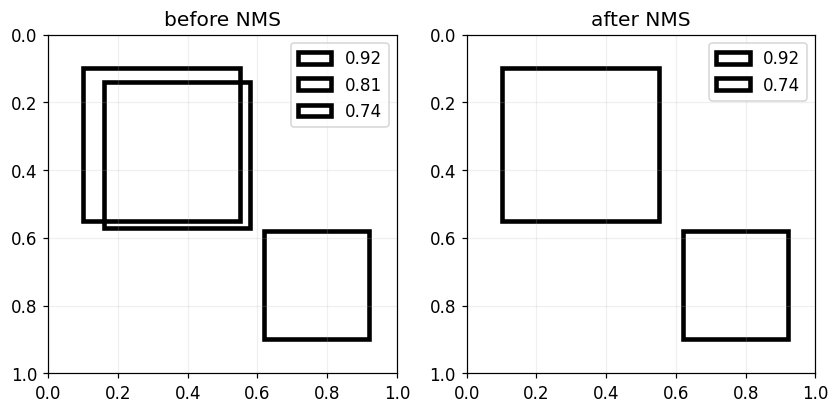

In [3]:
from matplotlib.patches import Rectangle
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, ids, title in [(axes[0], range(3), 'before NMS'), (axes[1], keep, 'after NMS')]:
    for i in ids:
        x1,y1,x2,y2 = boxes[i]
        ax.add_patch(Rectangle((x1,y1), x2-x1, y2-y1, fill=False, lw=3, label=f'{scores[i]:.2f}'))
    ax.set(xlim=(0,1), ylim=(1,0), title=title); ax.legend()
savefig('15_detection_demo')
report('vision_detection', {'keep': keep, 'iou_0_1': iou(boxes[0], boxes[1])})

## 解讀與延伸

先描述圖或表直接支持的結果，再說明這個縮編實驗不能代表完整模型的哪些面向。